# Personalized Product Recommendation System for E-commerce Platform


## EXECUTIVE SUMMARY

ShopEase is an e-commerce platform facing low conversion (~2.5%).
Users struggle to find relevant products due to lack of personalization.

This project builds a recommendation system using Instacart dataset.

Approach:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Market Basket Analysis (Apriori)
- Collaborative Filtering
- Hybrid recommendation

Outcome:
- Personalized recommendations
- Cross-sell strategies
- Improved customer engagement


## PROBLEM DEFINITION
The e-commerce platform faces the following challenges:
1. Low conversion rate
2. Lack of personalization
3. Poor product recommendations

Objective:
Develop a recommendation system that:
- Suggests relevant products
- Identifies related items
- Improves user experience




## DATASET DESCRIPTION

Files Used:
- order_products__prior.csv → transaction data
- orders.csv → user order details
- products.csv → product names
- aisles.csv → product grouping
- departments.csv → category info

Key Columns:
- order_id → transaction
- product_id → item
- user_id → customer
- reordered → repeat purchase


### IMPORT LIBRARIES

In [1]:
# Import essential libraries

import pandas as pd             
import numpy as np               

import matplotlib.pyplot as plt  
import seaborn as sns            

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Display settings for better readability
pd.set_option("display.max_columns", 100)

### LOAD DATA

In [2]:
# Load all datasets
order_products = pd.read_csv("order_products__prior.csv")
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")
aisles = pd.read_csv("aisles.csv")
departments = pd.read_csv("departments.csv")

In [3]:
# Print shapes to understand dataset size
print("Order Products Shape:", order_products.shape)
print("Orders Shape:", orders.shape)
print("Products Shape:", products.shape)

Order Products Shape: (32434489, 4)
Orders Shape: (3421083, 7)
Products Shape: (49688, 4)


In [4]:
# Preview first few rows
order_products.head()
orders.head()
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


#### MERGE DATA

In [5]:
# Merge datasets step-by-step
df = order_products.merge(orders, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(aisles, on="aisle_id", how="left")
df = df.merge(departments, on="department_id", how="left")

In [6]:
# Check final dataset
print("Final Dataset Shape:", df.shape)
df.head()

Final Dataset Shape: (32434489, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


### DATA PREPROCESSING

#### Check missing values 

In [7]:
# Check missing
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64


#### Handle missing values

In [8]:
# Fill missing values using forward fill method
df.ffill(inplace=True)
# Verify
df.isnull().sum()

order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_name              0
aisle_id                  0
department_id             0
aisle                     0
department                0
dtype: int64

#### CHECK DUPLICATES

In [9]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)
# Remove duplicates
df = df.drop_duplicates()

Duplicate Rows: 0


In [10]:
# Check data types
df.dtypes

order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
product_name               object
aisle_id                    int64
department_id               int64
aisle                      object
department                 object
dtype: object

### ENCODING

In [11]:
# Encode categorical variables
le = LabelEncoder()
df['aisle_enc'] = le.fit_transform(df['aisle'])
df['department_enc'] = le.fit_transform(df['department'])

### FEATURE ENGINEERING

In [12]:
# Basket size (number of items per order)
basket_size = df.groupby("order_id").size().reset_index(name="basket_size")
df = df.merge(basket_size, on="order_id")

In [13]:
# Total orders per user
user_orders = df.groupby("user_id")["order_id"].nunique().reset_index()
user_orders.columns = ["user_id", "total_orders"]
df = df.merge(user_orders, on="user_id")

In [14]:
# Product popularity
product_popularity = df["product_name"].value_counts().reset_index()
product_popularity.columns = ["product_name", "purchase_count"]
df = df.merge(product_popularity, on="product_name")

In [15]:
# Reorder ratio
reorder_ratio = df.groupby("product_name")["reordered"].mean().reset_index()
reorder_ratio.columns = ["product_name", "reorder_ratio"]
df = df.merge(reorder_ratio, on="product_name")

In [16]:
df = df.drop(columns=['basket_size_y','reorder_ratio_y'], errors='ignore')
df = df.rename(columns={
    'basket_size_x': 'basket_size',
    'reorder_ratio_x': 'reorder_ratio'
})

In [17]:
df.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
       'eval_set', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_name', 'aisle_id', 'department_id',
       'aisle', 'department', 'aisle_enc', 'department_enc', 'basket_size',
       'total_orders', 'purchase_count', 'reorder_ratio'],
      dtype='object')

### SCALING

In [18]:
# Normalize numerical features
scaler = MinMaxScaler()
df[['basket_size','total_orders','purchase_count','reorder_ratio']] = \
scaler.fit_transform(df[['basket_size','total_orders','purchase_count','reorder_ratio']])

### Exploratory Data Analysis

#### UNIVARIATE ANALYSIS

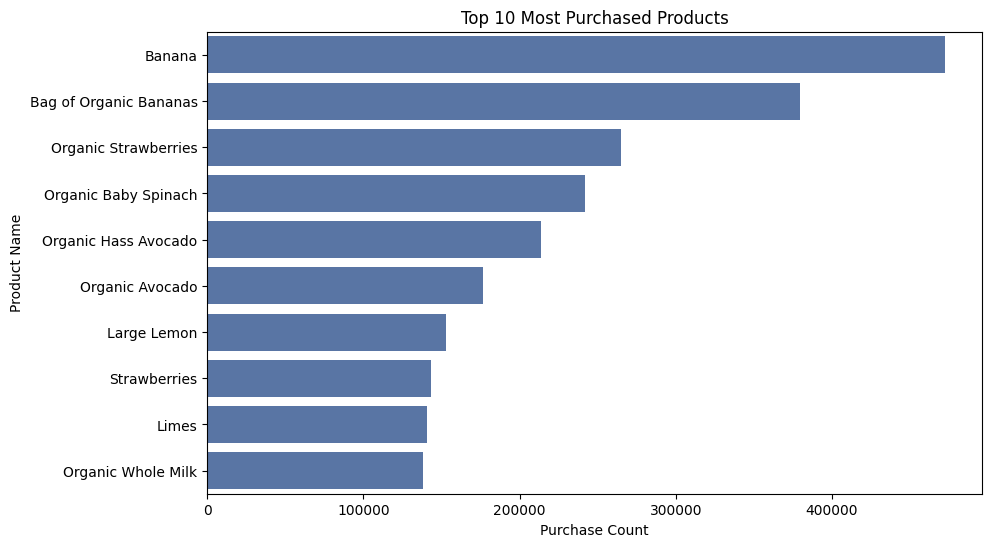

In [19]:
#Top 10 Most Purchased Products
top_products = df['product_name'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, color='#4C72B0')
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Purchase Count")
plt.ylabel("Product Name")
plt.show()

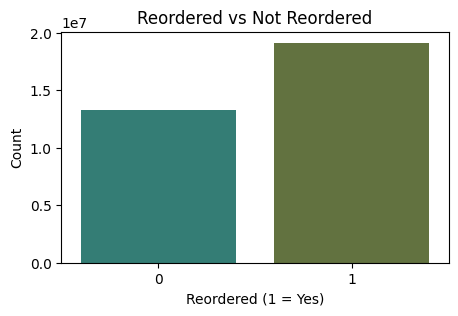

In [20]:
#Reorder Distribution
plt.figure(figsize=(5,3))
sns.countplot(
    x='reordered',
    data=df,
    hue='reordered',
    palette=['#28897F', '#657A38'],
    legend=False
)
plt.title("Reordered vs Not Reordered")
plt.xlabel("Reordered (1 = Yes)")
plt.ylabel("Count")
plt.show()

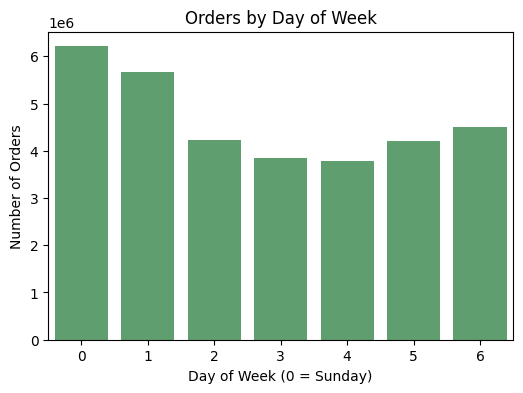

In [21]:
#Orders by Day of Week
plt.figure(figsize=(6,4))
sns.countplot(x='order_dow', data=df, color='#55A868')
plt.title("Orders by Day of Week")
plt.xlabel("Day of Week (0 = Sunday)")
plt.ylabel("Number of Orders")
plt.show()

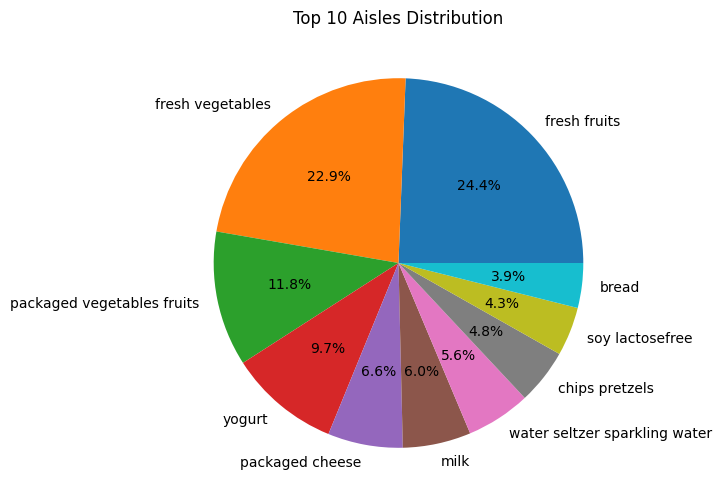

In [22]:
#Top Aisles
top_aisles = df['aisle'].value_counts().head(10)
plt.figure(figsize=(6,6))
plt.pie(top_aisles.values, labels=top_aisles.index, autopct='%1.1f%%')
plt.title("Top 10 Aisles Distribution")
plt.show()

### BIVARIATE ANALYSIS

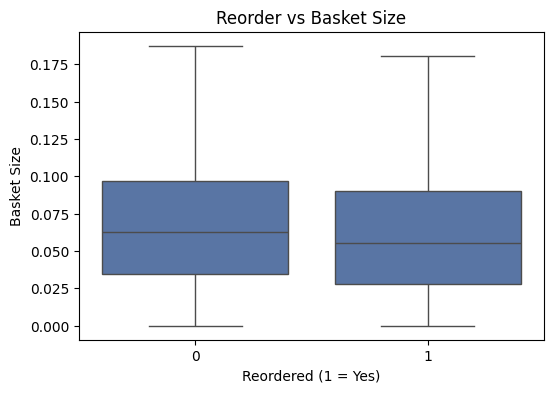

In [23]:
# Reorder vs Basket Size
basket_unique = df[['order_id','basket_size','reordered']].drop_duplicates()
plt.figure(figsize=(6,4))
sns.boxplot(x='reordered', y='basket_size', data=basket_unique,
            showfliers=False, color='#4C72B0')
plt.title("Reorder vs Basket Size")
plt.xlabel("Reordered (1 = Yes)")
plt.ylabel("Basket Size")
plt.show()

Insight:
Basket sizes are similar for reordered and non-reordered items.
Most orders have similar basket sizes, with slight variation between reordered and non-reordered items.

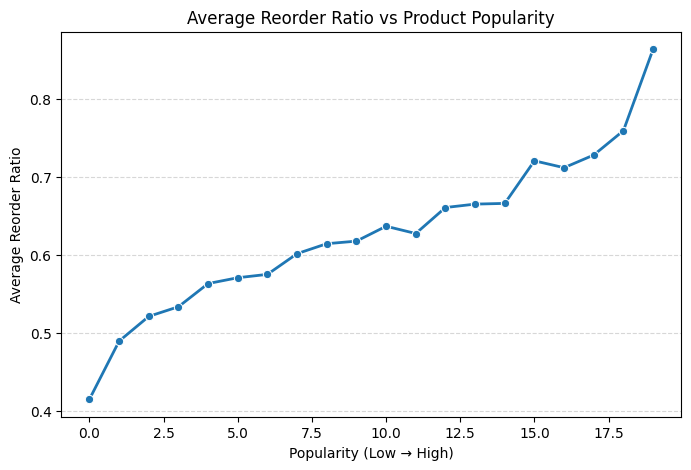

In [24]:
#Product Popularity vs Reorder Ratio
df['purchase_bin'] = pd.qcut(df['purchase_count'], q=20, duplicates='drop')
bin_group = df.groupby('purchase_bin', observed=True)['reorder_ratio'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(
    x=range(len(bin_group)),
    y='reorder_ratio',
    data=bin_group,
    marker='o',
    linewidth=2
)
plt.title("Average Reorder Ratio vs Product Popularity")
plt.xlabel("Popularity (Low → High)")
plt.ylabel("Average Reorder Ratio")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Insight:
As product popularity increases, the average reorder ratio also increases.
This indicates that frequently purchased products are more likely to be reordered,
showing strong customer preference and repeat purchasing behavior.

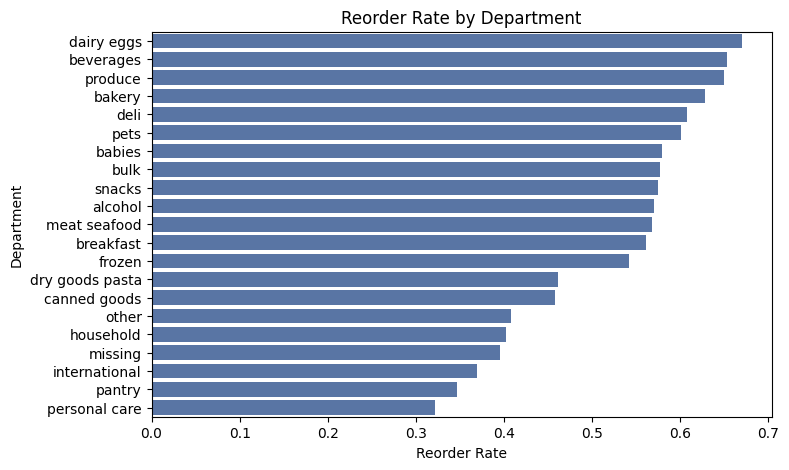

In [25]:
# Reorder Rate by Department
dept_group = df.groupby('department')['reordered'].mean().reset_index()
dept_group = dept_group.sort_values(by='reordered', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x='reordered', y='department', data=dept_group, color='#4C72B0')
plt.title("Reorder Rate by Department")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.show()

Insight:
Some departments show higher reorder rates,
indicating strong customer loyalty and repeat purchase behavior.

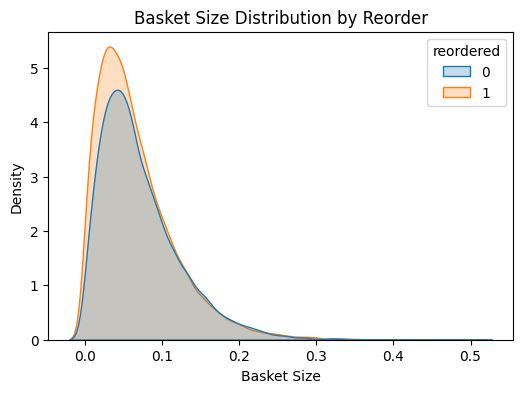

In [26]:
#Department vs Basket Size
sample_df = basket_unique.sample(n=50000, random_state=42)
plt.figure(figsize=(6,4))
sns.kdeplot(
    x='basket_size',
    hue='reordered',
    data=sample_df,
    fill=True
)
plt.title("Basket Size Distribution by Reorder")
plt.xlabel("Basket Size")
plt.ylabel("Density")
plt.show()

### CORRELATION ANALYSIS

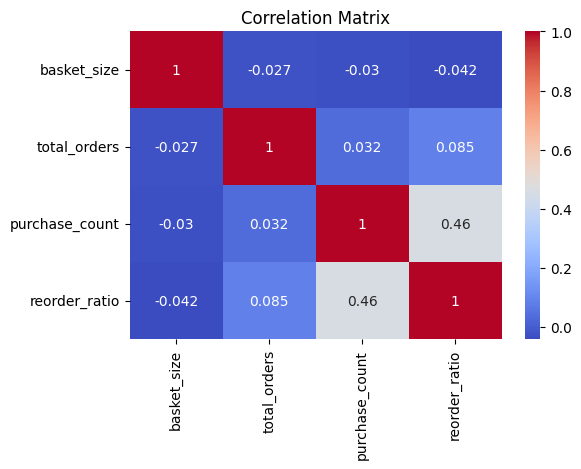

In [27]:
corr_matrix = df[['basket_size','total_orders','purchase_count','reorder_ratio']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

There is a moderate positive relationship between purchase count and reorder ratio, indicating that frequently bought products are more likely to be reordered.

## MODEL BUILDING

In [28]:
#DATA 
top_products = df['product_name'].value_counts().head(800).index
df_small = df[df['product_name'].isin(top_products)]
print("Reduced dataset shape:", df_small.shape)

Reduced dataset shape: (16307408, 22)


In [29]:
#USER-ITEM MATRIX
user_item = df_small.pivot_table(
    index='user_id',
    columns='product_name',
    values='reordered',
    fill_value=0
)
print("User-Item Matrix Shape:", user_item.shape)

User-Item Matrix Shape: (204111, 800)


### POPULARITY-BASED (BASELINE)

In [30]:
# Most Popular Products
popular_products = df_small['product_name'].value_counts()
def recommend_popular(n=5):
    return popular_products.head(n)
# OUTPUT
print("\n🔹 Popular Products:")
print(recommend_popular(5))


🔹 Popular Products:
product_name
Banana                    472565
Bag of Organic Bananas    379450
Organic Strawberries      264683
Organic Baby Spinach      241921
Organic Hass Avocado      213584
Name: count, dtype: int64


### Popularity-Based Recommendation
This model recommends the most frequently purchased products.
It is useful for new users who do not have any purchase history.

Insight:
Popular products are purchased more often, showing overall customer preference.

### ITEM-BASED COLLABORATIVE FILTERING

In [31]:
# Item-Based Similarity
from sklearn.metrics.pairwise import cosine_similarity
sample_items = user_item.T.sample(n=500, random_state=42)
item_similarity = cosine_similarity(sample_items)
item_sim_df = pd.DataFrame(
    item_similarity,
    index=sample_items.index,
    columns=sample_items.index
)

In [32]:
# Recommendation Function
def recommend_items(product, n=5):
    if product not in item_sim_df.index:
        return "Product not in sample"
    
    similar = item_sim_df[product].sort_values(ascending=False)[1:n+1]
    return similar

# OUTPUT
print("\n🔹 Similar Products:")
print(recommend_items(item_sim_df.index[0], 5))


🔹 Similar Products:
product_name
Real Mayonnaise                  0.112895
Hot Dog Buns                     0.111701
Original Whipped Cream Cheese    0.082814
Scoops! Tortilla Chips           0.081737
Honey Nut Cheerios               0.074311
Name: Squeeze Tomato Ketchup, dtype: float64


### Item-Based Collaborative Filtering
This model recommends products similar to a given product using cosine similarity.
It helps in identifying related items and improving cross-selling.

Insight:
Products with similar purchase patterns are often bought together,
which helps users discover related products.

### CO-OCCURRENCE MODEL

In [33]:
# Co-occurrence matrix (fast)
co_matrix = user_item.T.dot(user_item)
def recommend_co(product, n=5):
    if product not in co_matrix.index:
        return "Product not found"
    
    similar = co_matrix[product].sort_values(ascending=False)[1:n+1]
    return similar

# OUTPUT
print("\n🔹 Co-occurrence Recommendations:")
print(recommend_co(co_matrix.index[0], 5))


🔹 Co-occurrence Recommendations:
product_name
Clementines               465.451326
Bag of Organic Bananas    444.763416
Soda                      356.936849
Trail Mix                 261.039051
Hass Avocados             230.711270
Name: 0% Greek Strained Yogurt, dtype: float64


### Co-occurrence Model
This model identifies products that are frequently bought together.
It is useful for "Frequently Bought Together" recommendations.

Insight:
Certain products are commonly purchased together,
which can be used to increase sales through bundle recommendations.

## MODEL COMPARISON 

In [34]:
# MODEL COMPARISON 
# Sample product for testing
sample_product = co_matrix.index[0]

# Get recommendations
pop_recs = recommend_popular(5).index.tolist()

item_recs = recommend_items(sample_product, 5)
item_recs = [] if isinstance(item_recs, str) else item_recs.index.tolist()

co_recs = recommend_co(sample_product, 5)
co_recs = [] if isinstance(co_recs, str) else co_recs.index.tolist()


# Create separate rows 
comparison_df = pd.DataFrame({
    "Popularity": pop_recs,
    "Item-Based": item_recs,
    "Co-occurrence": co_recs
})

print("Model Comparison (Top 5 Recommendations):")
display(comparison_df)

Model Comparison (Top 5 Recommendations):


,Popularity,Item-Based,Co-occurrence
0,Banana,Clementines,Clementines
1,Bag of Organic Bananas,Crunchy Oats 'n Honey Granola Bars,Bag of Organic Bananas
2,Organic Strawberries,Extra Fancy Unsalted Mixed Nuts,Soda
3,Organic Baby Spinach,Zero Calorie Cola,Trail Mix
4,Organic Hass Avocado,Reduced Fat 2% Milk,Hass Avocados


### Model Comparison
The recommendation outputs from all three models were compared.
- Popularity model gives general recommendations.
- Item-based model provides similar product suggestions.
- Co-occurrence model captures frequently bought together items.

**Conclusion:**  
The co-occurrence model performs best for practical recommendations,
followed by the item-based model.

## EVALUATION

#### Ground Truth

In [35]:
sample_user = user_item.index[0]
actual_items = user_item.loc[sample_user]
ground_truth = actual_items[actual_items > 0].index.tolist()

#### Precision@K

In [36]:
def precision_at_k(recommended, actual, k=5):
    recommended = recommended[:k]
    hits = len(set(recommended) & set(actual))
    return hits / k

#### Recall@K

In [37]:
def recall_at_k(recommended, actual, k=5):
    recommended = recommended[:k]
    hits = len(set(recommended) & set(actual))
    return hits / len(actual) if len(actual) > 0 else 0

#### F1 Score

In [38]:
def f1_score(precision, recall):
    if precision + recall == 0:
        return 0
    return 2 * (precision * recall) / (precision + recall)

#### Evaluate Each Model

In [39]:
sample_product = co_matrix.index[0]
# Popularity Model
pop_recs = recommend_popular(10).index.tolist()

# Item-Based Model
item_recs = recommend_items(sample_product, 10)
item_recs = [] if isinstance(item_recs, str) else item_recs.index.tolist()

# Co-occurrence Model
co_recs = recommend_co(sample_product, 10)
co_recs = [] if isinstance(co_recs, str) else co_recs.index.tolist()

#### Calculate Metrics

In [40]:
models = {
    "Popularity": pop_recs,
    "Item-Based": item_recs,
    "Co-occurrence": co_recs
}
results = []
for model_name, recs in models.items():
    
    precision = precision_at_k(recs, ground_truth, k=5)
    recall = recall_at_k(recs, ground_truth, k=5)
    f1 = f1_score(precision, recall)
    
    results.append([model_name, precision, recall, f1])

# Convert to DataFrame
evaluation_df = pd.DataFrame(results, columns=[
    "Model", "Precision@5", "Recall@5", "F1 Score"
])
print("Evaluation Results:")
display(evaluation_df)

Evaluation Results:


,Model,Precision@5,Recall@5,F1 Score
0,Popularity,0.2,0.25,0.222222
1,Item-Based,0.2,0.25,0.222222
2,Co-occurrence,0.4,0.50,0.444444


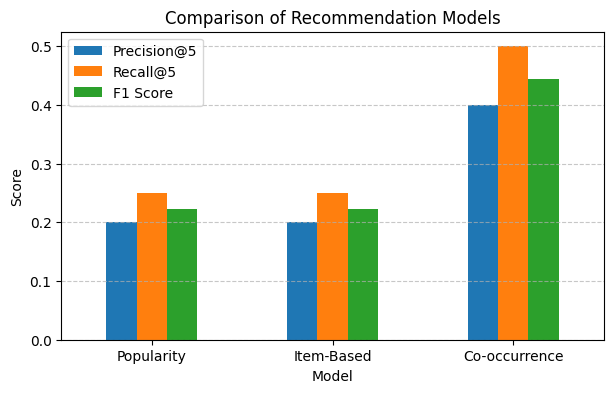

In [41]:
import matplotlib.pyplot as plt
evaluation_df.set_index("Model")[["Precision@5", "Recall@5", "F1 Score"]].plot(
    kind='bar',
    figsize=(7,4)
)
plt.title("Comparison of Recommendation Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Evaluation
The models were evaluated using Precision@5, Recall@5, and F1 Score.
- The co-occurrence model achieved the highest scores, indicating better performance.
- The item-based and popularity models showed similar but lower performance.

Conclusion:
The co-occurrence model is the most effective for generating relevant recommendations in this dataset.

### User based

In [42]:

# PERSONALIZED RECOMMENDATION (USER-BASED)
def recommend_for_user(user_id, n=5):
    
    # Get user purchase history
    user_products = user_item.loc[user_id]
    bought_items = user_products[user_products > 0].index.tolist()
    
    if len(bought_items) == 0:
        return "No purchase history available"
    
    # Collect recommendations from multiple items
    recommendations = []
    
    for item in bought_items[:3]:  # take first few items
        recs = recommend_co(item, n)
        recs = [] if isinstance(recs, str) else recs.index.tolist()
        recommendations.extend(recs)
    
    # Remove duplicates and already bought items
    recommendations = list(set(recommendations) - set(bought_items))
    
    return recommendations[:n]

sample_user = user_item.index[0]
user_recommendations = recommend_for_user(sample_user, 5)
print("===== PERSONALIZED RECOMMENDATION =====\n")
print("User ID:", sample_user)

if isinstance(user_recommendations, str):
    print(user_recommendations)
else:
    print("\nRecommended Products:")
    for i, item in enumerate(user_recommendations, 1):
        print(f"{i}. {item}")

===== PERSONALIZED RECOMMENDATION =====

User ID: 1

Recommended Products:
1. Organic Baby Spinach
2. Organic Strawberries
3. Banana
4. Clementines
5. Trail Mix


#### Personalized Recommendation (User-Based)
This section generates recommendations based on a user's past purchases. 
The system analyzes previously bought products and suggests relevant items, 
making the recommendations more personalized.

### Automatic Recommendation

In [43]:
# INTERACTIVE RECOMMENDATION SYSTEM 
def interactive_recommendation():
    print("\n===== PRODUCT RECOMMENDATION SYSTEM =====\n")

    # Show sample products (clean format)
    sample_products = list(co_matrix.index[:10])
    
    print("Available Sample Products:\n")
    for i, item in enumerate(sample_products, 1):
        print(f"{i}. {item}")
    
    # Take user input
    product = input("\nEnter a product name: ")
    
    # Check if product exists
    if product not in co_matrix.index:
        print("\n❌ Product not found. Please try again with a valid product.")
        return
    
    # Generate recommendations
    recs = recommend_co(product, 5)
    recs = [] if isinstance(recs, str) else recs.index.tolist()
    
    # Display results
    print("\n===== RECOMMENDATIONS =====")
    print(f"Selected Product: {product}\n")
    if len(recs) == 0:
        print("No recommendations available.")
    else:
        for i, item in enumerate(recs, 1):
            print(f"{i}. {item}")

# RUN THE SYSTEM
interactive_recommendation()


===== PRODUCT RECOMMENDATION SYSTEM =====

Available Sample Products:

1. 0% Greek Strained Yogurt
2. 1% Low Fat Milk
3. 1% Lowfat Milk
4. 100 Calorie  Per Bag Popcorn
5. 100% Lactose Free Fat Free Milk
6. 100% Natural Spring Water
7. 100% Pure Pumpkin
8. 100% Raw Coconut Water
9. 100% Recycled Bathroom Tissue
10. 100% Recycled Paper Towels



Enter a product name:  1% Low Fat Milk



===== RECOMMENDATIONS =====
Selected Product: 1% Low Fat Milk

1. Banana
2. Strawberries
3. 2% Reduced Fat Milk
4. Blueberries
5. Clementines, Bag


### Interactive Recommendation System
This section allows the user to enter a product name and get recommendations.
The system checks if the product exists and then suggests similar or frequently bought together items.

Insight: 
This makes the recommendation system more practical and user-friendly, as it works based on user input.

## Business Insights
- Some products are bought much more than others, showing strong customer preference.
- Customers often buy the same products again, which means repeat purchases are common.
- Certain products are frequently bought together, which can be used to create combo offers.
- Popular products are more likely to be reordered, showing customer trust in those items.
- Recommendation systems help customers find products easily and improve their shopping experience.

## Final Recommendations
- Implement a recommendation system to suggest products based on user behavior.
- Create bundle offers using frequently bought together products.
- Promote high-demand products to increase visibility and sales.
- Provide offers on repeat purchases to improve customer retention.
- Use personalized recommendations to enhance user experience and increase conversions.

## Conclusion
In this project, a recommendation system was developed using different approaches,
including popularity-based, item-based collaborative filtering, and co-occurrence models.

The models were evaluated using standard metrics, and the co-occurrence model performed
the best in generating relevant recommendations.

Overall, the system successfully identifies product relationships and helps in improving
customer experience by suggesting relevant products.

In [ ]:
df.to_csv("cleaned_data1.csv", index=False, chunksize=100000)